<a href="https://colab.research.google.com/github/Neurotech-BCI/ErrP/blob/main/MI_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install mne pyriemann

In [3]:
import numpy as np
import random
seed = 42
random.seed(seed)
np.random.seed(seed)

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [12]:
from pathlib import Path
import re
import pandas as pd

participant = "churek"

# Assumes you have a shortcut setup to outermost data/ dir under the neurotech BCI Project directory.
directory_path = Path('/content/drive/MyDrive/data/Mi Game')
data_files = sorted(str(file_path.resolve()) for file_path in directory_path.rglob('*.edf'))
data_files = [f for f in data_files if participant in f.lower()]

def infer_participant_name(edf_path: str) -> str:
    stem = Path(edf_path).stem.lower().replace('_raw', '')

    # Pattern like: 03_09_26_mi_omer_raw.edf
    m = re.search(r'mi_([a-z]+)', stem)
    if m:
        return m.group(1)

    # Fallback pattern like: 26_03_06_nihitha_raw.edf
    tokens = re.split(r'[_\-]', stem)
    alpha_tokens = [t for t in tokens if t.isalpha() and t not in {'mi', 'raw'}]
    return alpha_tokens[-1] if alpha_tokens else 'unknown'

def infer_session_label(edf_path: str) -> str:
    return Path(edf_path).stem.replace('_raw', '')

file_manifest = pd.DataFrame({
    'file_id': range(len(data_files)),
    'path': data_files,
    'participant': [infer_participant_name(p) for p in data_files],
    'session': [infer_session_label(p) for p in data_files],
})

print(f'Total EDF files: {len(file_manifest)}')
display(file_manifest[['file_id', 'participant', 'session', 'path']])

print('\nSessions per participant:')
display(file_manifest.groupby('participant', as_index=False)['session'].nunique().rename(columns={'session': 'n_sessions'}))

Total EDF files: 3


,file_id,participant,session,path
0,0,churek,03_09_26_mi_churek_2,/content/drive/.shortcut-targets-by-id/1Of26ja...
1,1,churek,03_09_26_mi_churek,/content/drive/.shortcut-targets-by-id/1Of26ja...
2,2,churek,03_24_26_mi_churek,/content/drive/.shortcut-targets-by-id/1Of26ja...



Sessions per participant:


,participant,n_sessions
0,churek,3


In [13]:
event_id = {
  "left": 1,
  "right": 2,
}

In [15]:
import mne
import numpy as np

def load_raw_edf(edf_file_path):
  data = mne.io.read_raw_edf(edf_file_path, preload = True)
  print(data.info)
  print(f"Original channel names: {data.info.ch_names}")

  ### Reference to Left Ear channel, default is Pz ###
  data.set_eeg_reference(ref_channels=['EEG LE-Pz'])

  ### Standardize channel names ###
  rename_dict = {}
  for ch_name in data.ch_names:
      if '-Pz' in ch_name:
          rename_dict[ch_name] = ch_name.replace('-Pz', '')
      if ch_name == "Pz":
          rename_dict[ch_name] = "EEG Pz"
  data.rename_channels(rename_dict)
  print(f"Updated channel names: {data.info.ch_names}")

  ### Preprocess with bandpass ###
  data.filter(l_freq=8.0, h_freq=30.0, picks="eeg")

  ### Find events labeled in the Trigger column ###
  events = mne.find_events(data, stim_channel='Trigger', min_duration=0.0)
  print(f'Found {len(events)} events')
  print(f'Event IDs: {set(events[:, 2])}')
  print(f"Event Counts: {mne.count_events(events)}")
  ### Create epochs time locked to the event triggers ###
  epochs = mne.Epochs(
      data,
      events,
      event_id=event_id,
      tmin=0.0,      # Start 200 ms before event
      tmax=3.0,       # End 800 ms after event
      baseline=(0.0, 0.0),  # Baseline period for correction
      preload=True
  )
  channels = ['EEG F4', 'EEG C4', 'EEG P4', 'EEG P3', 'EEG C3', 'EEG F3', 'EEG Pz']
  epochs = epochs.pick(channels)

  ### Plot epochs ###
  evokeds = [epochs[cond].average() for cond in list(event_id.keys())]
  mne.viz.plot_compare_evokeds(evokeds)

  ### Convert epochs and event labels to numpy ###
  samples = []
  labels = []
  for key in event_id.keys():
        datum = epochs[key].get_data()[:,:,:-1]
        samples.append(datum)
        labels.extend([key]*datum.shape[0])
  X = np.concatenate(samples, axis=0)
  y = np.array(labels)

  return X, y



Loading file #1/3: participant=churek, session=03_09_26_mi_churek_2
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/03_09_26_mi_churek_2_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 316799  =      0.000 ...  1055.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-09 18:30:23 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', '

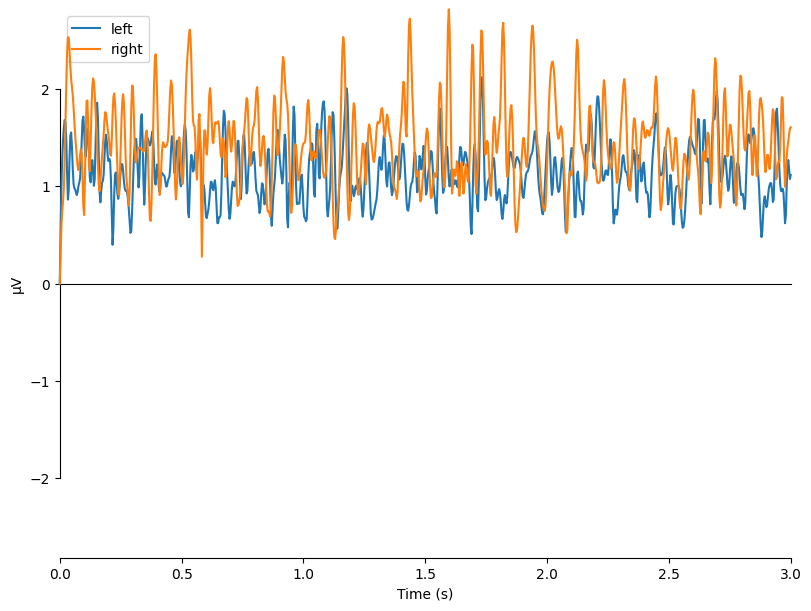

Loading file #2/3: participant=churek, session=03_09_26_mi_churek
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/03_09_26_mi_churek_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 296999  =      0.000 ...   989.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-09 18:12:35 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG 

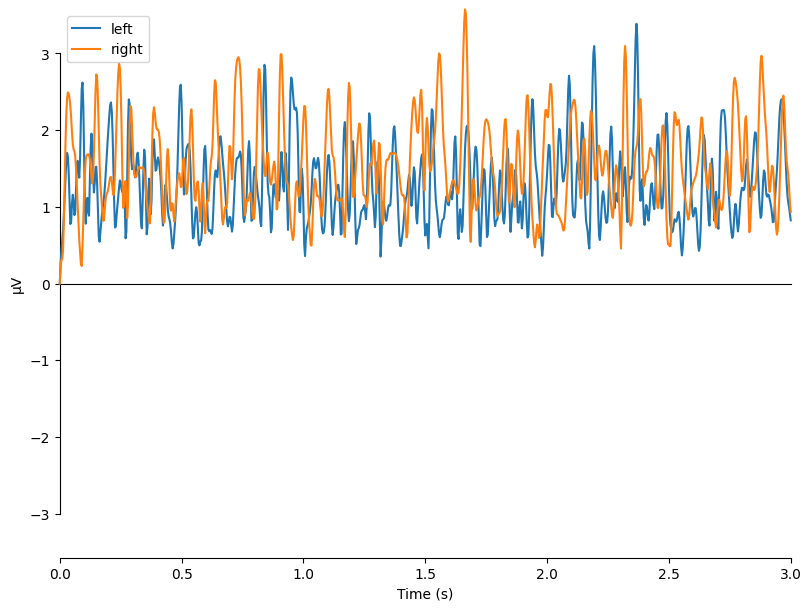

Loading file #3/3: participant=churek, session=03_24_26_mi_churek
Extracting EDF parameters from /content/drive/.shortcut-targets-by-id/1Of26ja31CLsHmwPpgDb0EavcVGfZdijv/data/Mi Game/03_24_26_mi_churek_raw.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 360599  =      0.000 ...  1201.997 secs...
<Info | 8 non-empty values
 bads: []
 ch_names: EEG LE-Pz, EEG F4-Pz, EEG C4-Pz, EEG P4-Pz, EEG P3-Pz, EEG ...
 chs: 12 EEG, 1 Stimulus
 custom_ref_applied: False
 highpass: 0.0 Hz
 lowpass: 150.0 Hz
 meas_date: 2026-03-24 17:10:41 UTC
 nchan: 13
 projs: []
 sfreq: 300.0 Hz
 subject_info: <subject_info | his_id: X, sex: 1, last_name: X, birthday: 2000-01-01>
>
Original channel names: ['EEG LE-Pz', 'EEG F4-Pz', 'EEG C4-Pz', 'EEG P4-Pz', 'EEG P3-Pz', 'EEG C3-Pz', 'EEG F3-Pz', 'Pz', 'Trigger', 'Event', 'Ax', 'Ay', 'Az']
EEG channel type selected for re-referencing
Applying a custom ('EEG',) reference.
Updated channel names: ['EEG LE', 'EEG F4', 'EEG C4', 'EEG 

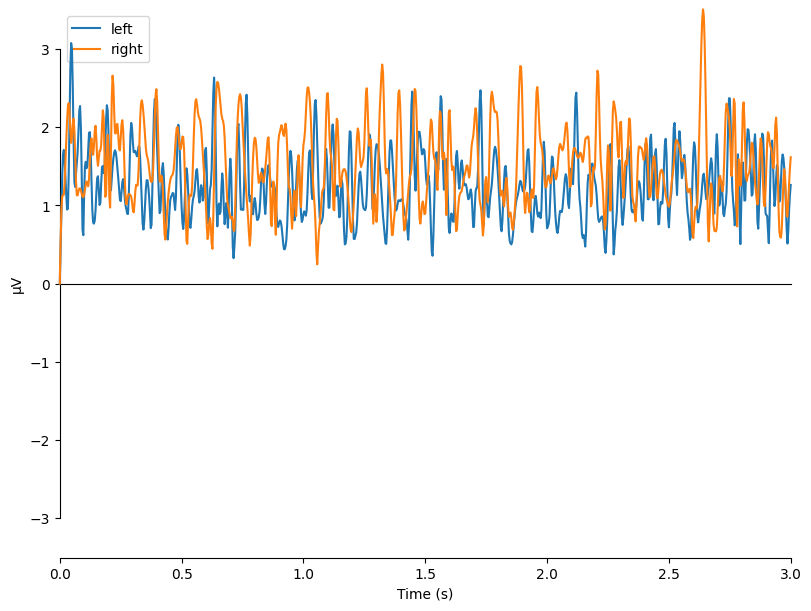


Shape of EEG data (num_trials, num_channels, epoch_len): (300, 7, 900)
Shape of labels array (num_trials,): (300,)
Shape of participant_groups array: (300,)
Shape of session_groups array: (300,)

Dataset class label counts:
[['left' '150']
 ['right' '150']]

Participant ID mapping:


,participant_id,participant
0,0,churek



Session ID mapping:


,session_id,session
0,0,03_09_26_mi_churek
1,1,03_09_26_mi_churek_2
2,2,03_24_26_mi_churek



Trials per participant:


,participant,n_trials
0,churek,300



Trials per session:


,session,participant,n_trials
0,03_09_26_mi_churek,churek,100
1,03_09_26_mi_churek_2,churek,100
2,03_24_26_mi_churek,churek,100


In [16]:
import numpy as np

# Build participant/session mappings used throughout the notebook
participant_names = sorted(file_manifest['participant'].unique().tolist())
participant_to_id = {name: idx for idx, name in enumerate(participant_names)}
id_to_participant = {idx: name for name, idx in participant_to_id.items()}

session_names = sorted(file_manifest['session'].unique().tolist())
session_to_id = {name: idx for idx, name in enumerate(session_names)}
id_to_session = {idx: name for name, idx in session_to_id.items()}

X_list = []
y_list = []
participant_groups = []
session_groups = []
participant_labels = []
session_labels = []
source_file_ids = []

total_len = len(file_manifest)
for i, row in file_manifest.iterrows():
    data_file = row['path']
    participant = row['participant']
    session = row['session']

    print(f"Loading file #{i+1}/{total_len}: participant={participant}, session={session}")
    datum, label = load_raw_edf(data_file)

    X_list.append(datum)
    y_list.append(label)

    n_trials = datum.shape[0]
    participant_groups.extend([participant_to_id[participant]] * n_trials)
    session_groups.extend([session_to_id[session]] * n_trials)
    participant_labels.extend([participant] * n_trials)
    session_labels.extend([session] * n_trials)
    source_file_ids.extend([int(row['file_id'])] * n_trials)

X = np.concatenate(X_list, axis=0)
y = np.concatenate(y_list, axis=0)
participant_groups = np.array(participant_groups)
session_groups = np.array(session_groups)
participant_labels = np.array(participant_labels)
session_labels = np.array(session_labels)
source_file_ids = np.array(source_file_ids)

# Backward compatibility alias for older cells (participant-level grouping)
groups = participant_groups

print(f"\nShape of EEG data (num_trials, num_channels, epoch_len): {X.shape}")
print(f"Shape of labels array (num_trials,): {y.shape}")
print(f"Shape of participant_groups array: {participant_groups.shape}")
print(f"Shape of session_groups array: {session_groups.shape}")

unique_labels, counts = np.unique(y, return_counts=True)
print("\nDataset class label counts:")
print(np.asarray((unique_labels, counts)).T)

print("\nParticipant ID mapping:")
participant_lookup_df = pd.DataFrame({
    'participant_id': list(id_to_participant.keys()),
    'participant': list(id_to_participant.values()),
}).sort_values('participant_id')
display(participant_lookup_df)

print("\nSession ID mapping:")
session_lookup_df = pd.DataFrame({
    'session_id': list(id_to_session.keys()),
    'session': list(id_to_session.values()),
}).sort_values('session_id')
display(session_lookup_df)

print("\nTrials per participant:")
participant_trial_counts = (
    pd.DataFrame({'participant': participant_labels})
      .value_counts()
      .rename('n_trials')
      .reset_index()
      .sort_values(['n_trials', 'participant'], ascending=[False, True])
)
display(participant_trial_counts)

print("\nTrials per session:")
session_trial_counts = (
    pd.DataFrame({'session': session_labels, 'participant': participant_labels})
      .value_counts()
      .rename('n_trials')
      .reset_index()
      .sort_values(['n_trials', 'participant', 'session'], ascending=[False, True, True])
)
display(session_trial_counts)

In [17]:
y = [0 if lab == 'left' else 1 for lab in y]
y = np.array(y)
unique_labels, counts = np.unique(y,return_counts=True)
print("Dataset label counts:")
print(np.asarray((unique_labels, counts)).T)

Dataset label counts:
[[  0 150]
 [  1 150]]


In [21]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

### Within-Session Classification ###

def _make_classifier() -> Pipeline:
    return Pipeline([
        ("cov", Covariances(estimator="oas")),
        ("ts", TangentSpace(metric="riemann")),
        ("scaler", StandardScaler()),
        ("clf", LinearDiscriminantAnalysis()),
    ])

# X: shape (num_samples, num_channels, window_len)
# y: shape (num_samples,)
# session_groups: shape (num_samples,) -> session id for each sample

session_scores = {}
all_session_means = []

unique_sessions = np.unique(session_groups)

for session_id in unique_sessions:
    session_mask = session_groups == session_id
    X_session = X[session_mask]
    y_session = y[session_mask]
    session_name = id_to_session.get(int(session_id), f"session_{int(session_id)}")

    # Skip sessions that cannot support LOO classification
    if len(np.unique(y_session)) < 2:
        print(f"Session {session_name} (id={int(session_id)}): skipped (only one class present)")
        continue

    if len(y_session) < 2:
        print(f"Session {session_name} (id={int(session_id)}): skipped (fewer than 2 samples)")
        continue

    scores = cross_val_score(
        _make_classifier(),
        X_session,
        y_session,
        cv=LeaveOneOut(),
        scoring="accuracy",
        n_jobs=-1,
    )

    session_mean = scores.mean()
    session_std = scores.std()

    session_scores[session_id] = {
        "session_name": session_name,
        "fold_scores": scores,
        "mean": session_mean,
        "std": session_std,
        "n_samples": len(y_session),
    }
    all_session_means.append(session_mean)

print("Results by session:")
for session_id in unique_sessions:
    if session_id not in session_scores:
        continue
    result = session_scores[session_id]
    print(
        f"  Session {result['session_name']} (id={int(session_id)}): "
        f"accuracy={result['mean']:.3f} +/- {result['std']:.3f} "
        f"(n={result['n_samples']})"
    )

if all_session_means:
    print(f"\nAverage across sessions: {np.mean(all_session_means):.3f}")
    print(f"Std across sessions:     {np.std(all_session_means):.3f}")
else:
    print("\nNo valid sessions were evaluated.")

Results by session:
  Session 03_09_26_mi_churek (id=0): accuracy=0.910 +/- 0.286 (n=100)
  Session 03_09_26_mi_churek_2 (id=1): accuracy=0.850 +/- 0.357 (n=100)
  Session 03_24_26_mi_churek (id=2): accuracy=0.810 +/- 0.392 (n=100)

Average across sessions: 0.857
Std across sessions:     0.041


In [23]:
import numpy as np
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
import pandas as pd

# Cross-participant classification (hold out one participant at a time)

def _make_classifier() -> Pipeline:
    return Pipeline([
        ('cov', Covariances(estimator='oas')),
        ('ts', TangentSpace(metric='riemann')),
        ('scaler', StandardScaler()),
        ('clf', LinearDiscriminantAnalysis()),
    ])

unique_participants = np.unique(participant_groups)
if len(unique_participants) < 2:
    only_id = int(unique_participants[0]) if len(unique_participants) == 1 else None
    only_name = id_to_participant.get(only_id, 'unknown') if only_id is not None else 'none'

    print('Cross-participant holdout skipped: need at least 2 participants.')
    fallback = pd.DataFrame([
        {
            'status': 'skipped',
            'reason': 'not enough participants for LeaveOneGroupOut',
            'n_participants': int(len(unique_participants)),
            'participant_id': only_id,
            'participant': only_name,
        }
    ])
    display(fallback)
else:
    logo = LeaveOneGroupOut()
    rows = []

    for fold_idx, (tr, te) in enumerate(logo.split(X, y, groups=participant_groups), start=1):
        clf = _make_classifier()
        clf.fit(X[tr], y[tr])
        pred = clf.predict(X[te])

        held_out_id = int(np.unique(participant_groups[te])[0])
        held_out_name = id_to_participant.get(held_out_id, str(held_out_id))

        rows.append({
            'fold': fold_idx,
            'held_out_participant_id': held_out_id,
            'held_out_participant': held_out_name,
            'n_test': int(len(te)),
            'accuracy': float(accuracy_score(y[te], pred)),
            'balanced_acc': float(balanced_accuracy_score(y[te], pred)),
            'macro_f1': float(f1_score(y[te], pred, average='macro')),
        })

    cv_results = pd.DataFrame(rows).sort_values('balanced_acc', ascending=False).reset_index(drop=True)
    print('Cross-participant holdout results:')
    display(cv_results)

    print('\nOverall mean metrics:')
    print(f"accuracy     = {cv_results['accuracy'].mean():.3f} +/- {cv_results['accuracy'].std():.3f}")
    print(f"balanced_acc = {cv_results['balanced_acc'].mean():.3f} +/- {cv_results['balanced_acc'].std():.3f}")
    print(f"macro_f1     = {cv_results['macro_f1'].mean():.3f} +/- {cv_results['macro_f1'].std():.3f}")

Cross-participant holdout skipped: need at least 2 participants.


,status,reason,n_participants,participant_id,participant
0,skipped,not enough participants for LeaveOneGroupOut,1,0,churek


## Model Bakeoff (Per Participant + Cross Participant)
This section reproduces the model-suite comparison style from the experiments folder.

It evaluates:
- `riemann_lr`
- `riemann_lr_C0.1`
- `csp4_lda`
- `csp6_lda`
- `fbank_riemann`
- `fbank_riemann_wide`

Two views are reported:
1. Per-participant bakeoff (best model for each participant/session)
2. Cross-participant bakeoff (leave-one-participant-out generalization)

In [ ]:
import mne
from mne.decoding import CSP
from mne.filter import filter_data
from pyriemann.estimation import Covariances
from pyriemann.tangentspace import TangentSpace
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import StratifiedKFold, LeaveOneGroupOut
from sklearn.metrics import balanced_accuracy_score, f1_score
import pandas as pd

# Silence MNE informational logging globally for cleaner notebook output
mne.set_log_level('ERROR')


class FilterBankRiemannLR(BaseEstimator, ClassifierMixin):
    def __init__(self, sfreq=300.0, bands=((8, 12), (12, 16), (16, 20), (20, 28), (8, 30)), C=1.0):
        self.sfreq = float(sfreq)
        self.bands = tuple((float(a), float(b)) for a, b in bands)
        self.C = float(C)
        self.band_models_ = None
        self.scaler_ = None
        self.clf_ = None

    def fit(self, X, y):
        feats = []
        self.band_models_ = []
        for lo, hi in self.bands:
            Xf = filter_data(X.astype(np.float64), sfreq=self.sfreq, l_freq=lo, h_freq=hi, verbose='ERROR').astype(np.float32)
            cov = Covariances(estimator='oas')
            ts = TangentSpace(metric='riemann')
            z = ts.fit_transform(cov.fit_transform(Xf))
            self.band_models_.append((cov, ts, lo, hi))
            feats.append(z)
        Z = np.concatenate(feats, axis=1)
        self.scaler_ = StandardScaler().fit(Z)
        self.clf_ = LogisticRegression(
            C=self.C,
            max_iter=3000,
            solver='lbfgs',
            class_weight='balanced',
            random_state=42,
        )
        self.clf_.fit(self.scaler_.transform(Z), y)
        self.classes_ = self.clf_.classes_
        return self

    def _transform(self, X):
        feats = []
        for cov, ts, lo, hi in self.band_models_:
            Xf = filter_data(X.astype(np.float64), sfreq=self.sfreq, l_freq=lo, h_freq=hi, verbose='ERROR').astype(np.float32)
            feats.append(ts.transform(cov.transform(Xf)))
        return np.concatenate(feats, axis=1)

    def predict(self, X):
        Z = self._transform(X)
        return self.clf_.predict(self.scaler_.transform(Z))


def model_bank(n_ch, sfreq=300.0):
    return {
        'riemann_lr': Pipeline([
            ('cov', Covariances(estimator='oas')),
            ('ts', TangentSpace(metric='riemann')),
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(max_iter=3000, solver='lbfgs', class_weight='balanced', random_state=42)),
        ]),
        'riemann_lr_C0.1': Pipeline([
            ('cov', Covariances(estimator='oas')),
            ('ts', TangentSpace(metric='riemann')),
            ('sc', StandardScaler()),
            ('clf', LogisticRegression(C=0.1, max_iter=3000, solver='lbfgs', class_weight='balanced', random_state=42)),
        ]),
        'csp4_lda': Pipeline([
            ('csp', CSP(n_components=min(4, n_ch), reg='ledoit_wolf', log=True, norm_trace=False, verbose=False)),
            ('sc', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ]),
        'csp6_lda': Pipeline([
            ('csp', CSP(n_components=min(6, n_ch), reg='ledoit_wolf', log=True, norm_trace=False, verbose=False)),
            ('sc', StandardScaler()),
            ('clf', LinearDiscriminantAnalysis(solver='lsqr', shrinkage='auto')),
        ]),
        'fbank_riemann': FilterBankRiemannLR(sfreq=sfreq),
        'fbank_riemann_wide': FilterBankRiemannLR(sfreq=sfreq, bands=((6, 10), (10, 14), (14, 18), (18, 24), (24, 32), (8, 30))),
    }

print('Model bakeoff definitions loaded.')

Model bakeoff definitions loaded.


In [27]:
from IPython.display import display, Markdown
import io
import contextlib


def _quiet_fit_predict(estimator, X_train, y_train, X_test):
    # Suppress noisy library stdout/stderr (MNE/CSP internals)
    with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
        estimator.fit(X_train, y_train)
        return estimator.predict(X_test)


def cv_predict_binary(X, y, estimator, cv):
    y_pred = np.empty_like(y)
    for tr, te in cv.split(X, y):
        y_pred[te] = _quiet_fit_predict(estimator, X[tr], y[tr], X[te])
    return y_pred


def per_participant_bakeoff(X, y, participant_groups, id_to_participant, sfreq=300.0):
    rows = []
    for pid in np.unique(participant_groups):
        mask = participant_groups == pid
        Xp = X[mask]
        yp = y[mask]

        vals, cnts = np.unique(yp, return_counts=True)
        if len(vals) < 2:
            continue

        min_class = int(np.min(cnts))
        n_splits = max(2, min(5, min_class))
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
        models = model_bank(Xp.shape[1], sfreq=sfreq)
        pname = id_to_participant.get(int(pid), str(int(pid)))

        for model_name, est in models.items():
            try:
                yp_pred = cv_predict_binary(Xp, yp, est, cv)
                rows.append({
                    'participant_id': int(pid),
                    'participant': pname,
                    'model': model_name,
                    'bal_acc': float(balanced_accuracy_score(yp, yp_pred)),
                    'macro_f1': float(f1_score(yp, yp_pred, average='macro')),
                    'n_samples': int(len(yp)),
                })
            except Exception:
                continue

    return pd.DataFrame(rows)


def cross_participant_bakeoff(X, y, participant_groups, id_to_participant, sfreq=300.0):
    unique_participants = np.unique(participant_groups)
    if len(unique_participants) < 2:
        only_id = int(unique_participants[0]) if len(unique_participants) == 1 else None
        only_name = id_to_participant.get(only_id, 'unknown') if only_id is not None else 'none'
        summary = pd.DataFrame([
            {
                'model': 'N/A',
                'bal_acc': np.nan,
                'macro_f1': np.nan,
                'n_eval': 0,
                'status': 'skipped',
                'reason': 'not enough participants for LeaveOneGroupOut',
                'participant': only_name,
            }
        ])
        by_participant = pd.DataFrame([
            {
                'model': 'N/A',
                'held_out_participant_id': only_id,
                'held_out_participant': only_name,
                'n_test': int(len(y)),
                'bal_acc': np.nan,
                'macro_f1': np.nan,
                'status': 'skipped',
            }
        ])
        return summary, by_participant

    logo = LeaveOneGroupOut()
    fold_rows = []
    summary_rows = []
    models = model_bank(X.shape[1], sfreq=sfreq)

    for model_name, est in models.items():
        y_pred = np.empty_like(y)
        valid = np.zeros_like(y, dtype=bool)

        for tr, te in logo.split(X, y, groups=participant_groups):
            ytr = y[tr]
            if len(np.unique(ytr)) < 2:
                continue

            fold_pred = _quiet_fit_predict(est, X[tr], ytr, X[te])
            y_pred[te] = fold_pred
            valid[te] = True

            held_out_id = int(np.unique(participant_groups[te])[0])
            held_out_name = id_to_participant.get(held_out_id, str(held_out_id))
            fold_rows.append({
                'model': model_name,
                'held_out_participant_id': held_out_id,
                'held_out_participant': held_out_name,
                'n_test': int(len(te)),
                'bal_acc': float(balanced_accuracy_score(y[te], fold_pred)),
                'macro_f1': float(f1_score(y[te], fold_pred, average='macro')),
            })

        if np.sum(valid) == 0:
            continue

        summary_rows.append({
            'model': model_name,
            'bal_acc': float(balanced_accuracy_score(y[valid], y_pred[valid])),
            'macro_f1': float(f1_score(y[valid], y_pred[valid], average='macro')),
            'n_eval': int(np.sum(valid)),
        })

    by_participant = pd.DataFrame(fold_rows)
    summary = pd.DataFrame(summary_rows)

    if not by_participant.empty:
        by_participant = by_participant.sort_values(['model', 'held_out_participant']).reset_index(drop=True)
    if not summary.empty:
        summary = summary.sort_values('bal_acc', ascending=False).reset_index(drop=True)

    return summary, by_participant


def cross_session_within_participant_bakeoff(
    X,
    y,
    participant_groups,
    session_groups,
    id_to_participant,
    id_to_session,
    sfreq=300.0,
):
    fold_rows = []
    summary_rows = []

    for pid in np.unique(participant_groups):
        p_mask = participant_groups == pid
        Xp = X[p_mask]
        yp = y[p_mask]
        sp = session_groups[p_mask]
        pname = id_to_participant.get(int(pid), str(int(pid)))

        unique_sessions = np.unique(sp)
        if len(unique_sessions) < 2:
            summary_rows.append({
                'participant_id': int(pid),
                'participant': pname,
                'model': 'N/A',
                'bal_acc': np.nan,
                'macro_f1': np.nan,
                'n_eval': 0,
                'status': 'skipped',
                'reason': 'not enough sessions for LeaveOneGroupOut',
            })
            continue

        models = model_bank(Xp.shape[1], sfreq=sfreq)
        logo = LeaveOneGroupOut()

        for model_name, est in models.items():
            y_pred = np.empty_like(yp)
            valid = np.zeros_like(yp, dtype=bool)

            for tr, te in logo.split(Xp, yp, groups=sp):
                ytr = yp[tr]
                if len(np.unique(ytr)) < 2:
                    continue

                fold_pred = _quiet_fit_predict(est, Xp[tr], ytr, Xp[te])
                y_pred[te] = fold_pred
                valid[te] = True

                held_out_sid = int(np.unique(sp[te])[0])
                held_out_session = id_to_session.get(held_out_sid, str(held_out_sid))
                fold_rows.append({
                    'participant_id': int(pid),
                    'participant': pname,
                    'session': held_out_session,
                    'model': model_name,
                    'n_test': int(len(te)),
                    'bal_acc': float(balanced_accuracy_score(yp[te], fold_pred)),
                    'macro_f1': float(f1_score(yp[te], fold_pred, average='macro')),
                })

            if np.sum(valid) == 0:
                summary_rows.append({
                    'participant_id': int(pid),
                    'participant': pname,
                    'model': model_name,
                    'bal_acc': np.nan,
                    'macro_f1': np.nan,
                    'n_eval': 0,
                    'status': 'skipped',
                    'reason': 'training folds lacked both classes',
                })
                continue

            summary_rows.append({
                'participant_id': int(pid),
                'participant': pname,
                'model': model_name,
                'bal_acc': float(balanced_accuracy_score(yp[valid], y_pred[valid])),
                'macro_f1': float(f1_score(yp[valid], y_pred[valid], average='macro')),
                'n_eval': int(np.sum(valid)),
                'status': 'ok',
                'reason': '',
            })

    by_session = pd.DataFrame(fold_rows)
    summary = pd.DataFrame(summary_rows)

    if not by_session.empty:
        by_session = by_session.sort_values(['participant', 'model', 'session']).reset_index(drop=True)
    if not summary.empty:
        summary = summary.sort_values(['participant', 'bal_acc'], ascending=[True, False], na_position='last').reset_index(drop=True)

    return summary, by_session


def format_results(df, sort_cols=None):
    if df is None or df.empty:
        return df
    out = df.copy()
    if 'bal_acc' in out.columns:
        out['bal_acc'] = out['bal_acc'].round(4)
    if 'macro_f1' in out.columns:
        out['macro_f1'] = out['macro_f1'].round(4)
    if sort_cols:
        out = out.sort_values(sort_cols).reset_index(drop=True)
    return out


# ---- Run all evaluations ----
participant_results = per_participant_bakeoff(X, y, participant_groups, id_to_participant=id_to_participant, sfreq=300.0)
cross_summary, cross_by_participant = cross_participant_bakeoff(X, y, participant_groups, id_to_participant=id_to_participant, sfreq=300.0)
cross_session_summary, cross_session_by_fold = cross_session_within_participant_bakeoff(
    X,
    y,
    participant_groups,
    session_groups,
    id_to_participant=id_to_participant,
    id_to_session=id_to_session,
    sfreq=300.0,
)

# ---- Clean, interpretable result views ----
display(Markdown('### Result Guide'))
result_guide = pd.DataFrame([
    {
        'result_table': 'Within-participant model ranking',
        'training_data': 'Other folds from same participant',
        'test_data': 'Held-out folds from same participant',
        'metric_meaning': 'Mean over within-participant CV folds',
    },
    {
        'result_table': 'Cross-participant summary',
        'training_data': 'All other participants',
        'test_data': 'Held-out participant',
        'metric_meaning': 'Mean over held-out participants (LOPO)',
    },
    {
        'result_table': 'Cross-session within participant',
        'training_data': 'Other sessions of same participant',
        'test_data': 'Held-out session',
        'metric_meaning': 'Mean over held-out sessions for that participant',
    },
])
display(result_guide)


display(Markdown('### 1) Within-Participant Model Ranking (Mean Across Participants)'))
if participant_results is not None and not participant_results.empty:
    within_rank = (
        participant_results
        .groupby('model', as_index=False)[['bal_acc', 'macro_f1']]
        .mean()
        .sort_values('bal_acc', ascending=False)
        .reset_index(drop=True)
    )
    display(format_results(within_rank))
else:
    display(pd.DataFrame([{'status': 'no results'}]))


display(Markdown('### 2) Cross-Participant Summary (Train: other participants, Test: held-out participant)'))
if cross_summary is not None and not cross_summary.empty:
    display(format_results(cross_summary))
else:
    display(pd.DataFrame([{'status': 'no results'}]))


display(Markdown('### 3) Cross-Session Within Each Participant (Best Model Per Participant)'))
if cross_session_summary is not None and not cross_session_summary.empty:
    cross_session_ok = cross_session_summary[cross_session_summary.get('status', 'ok') == 'ok'].copy()
    if not cross_session_ok.empty:
        best_cross_session = (
            cross_session_ok
            .sort_values(['participant', 'bal_acc'], ascending=[True, False])
            .groupby(['participant_id', 'participant'], as_index=False)
            .first()
            .loc[:, ['participant_id', 'participant', 'model', 'bal_acc', 'macro_f1', 'n_eval']]
            .sort_values('participant_id')
            .reset_index(drop=True)
        )
        display(format_results(best_cross_session))
    else:
        display(format_results(cross_session_summary.loc[:, ['participant_id', 'participant', 'status', 'reason']].drop_duplicates()))
else:
    display(pd.DataFrame([{'status': 'no results'}]))

### Result Guide

,result_table,training_data,test_data,metric_meaning
0,Within-participant model ranking,Other folds from same participant,Held-out folds from same participant,Mean over within-participant CV folds
1,Cross-participant summary,All other participants,Held-out participant,Mean over held-out participants (LOPO)
2,Cross-session within participant,Other sessions of same participant,Held-out session,Mean over held-out sessions for that participant


### 1) Within-Participant Model Ranking (Mean Across Participants)

,model,bal_acc,macro_f1
0,riemann_lr_C0.1,0.9033,0.9033
1,riemann_lr,0.8967,0.8967
2,fbank_riemann_wide,0.8767,0.8767
3,fbank_riemann,0.8600,0.8600
4,csp4_lda,0.6867,0.6867
5,csp6_lda,0.6833,0.6833


### 2) Cross-Participant Summary (Train: other participants, Test: held-out participant)

,model,bal_acc,macro_f1,n_eval,status,reason,participant
0,N/A,NaN,NaN,0,skipped,not enough participants for LeaveOneGroupOut,churek


### 3) Cross-Session Within Each Participant (Best Model Per Participant)

,participant_id,participant,model,bal_acc,macro_f1,n_eval
0,0,churek,riemann_lr_C0.1,0.78,0.7747,300
